In [1]:
import pandas as pd
from pyspark.sql import SparkSession

In [2]:
!pip install pyspark

In [4]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Youtube_Analysis_Project").getOrCreate()

In [5]:
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
 print(f'user uploaded files "{fn}" with length {len(uploaded[fn])} bytes')



Saving youtube_2025_dashboard_dataset.xlsx to youtube_2025_dashboard_dataset.xlsx
user uploaded files "youtube_2025_dashboard_dataset.xlsx" with length 62768 bytes


In [6]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("YouTubeAnalysis").getOrCreate()

print("Spark started successfully")

Spark started successfully


In [7]:
!pip install openpyxl

In [8]:
import pandas as pd

pdf= pd.read_excel("youtube_2025_dashboard_dataset.xlsx")
pdf.head()

,Video_ID,Channel_Name,Category,Upload_Date,Country,Views,Likes,Comments,Shares,Impressions,CTR_%,Avg_Watch_Time_Min,Watch_Time_Hours,Subscribers_Gained,Revenue_$,Video_Length_Min
0,VID00001,FoodiesHub,Finance,2025-04-27,Germany,128909,12045,2555,5087,1320794,9.76,3.15,6767,4831,777.95,12.92
1,VID00002,FitnessPro,Education,2025-06-14,Germany,30280,3304,290,1454,288116,10.51,4.73,2387,386,125.45,12.49
2,VID00003,DailyVlogs,Travel,2025-02-06,India,36310,2134,208,843,1599584,2.27,11.18,6765,717,318.94,16.22
3,VID00004,TravelVlogs,Gaming,2025-04-26,India,154142,13695,1546,3264,1323111,11.65,6.25,16056,2708,490.24,10.08
4,VID00005,TechWorld,Finance,2025-06-22,USA,42400,5067,1244,1888,986051,4.30,7.96,5625,2202,236.91,15.27


In [9]:
df = spark.createDataFrame(pdf)
df.show(5)

+--------+------------+---------+-----------+-------+------+-----+--------+------+-----------+-----+------------------+----------------+------------------+---------+----------------+
|Video_ID|Channel_Name| Category|Upload_Date|Country| Views|Likes|Comments|Shares|Impressions|CTR_%|Avg_Watch_Time_Min|Watch_Time_Hours|Subscribers_Gained|Revenue_$|Video_Length_Min|
+--------+------------+---------+-----------+-------+------+-----+--------+------+-----------+-----+------------------+----------------+------------------+---------+----------------+
|VID00001|  FoodiesHub|  Finance| 2025-04-27|Germany|128909|12045|    2555|  5087|    1320794| 9.76|              3.15|            6767|              4831|   777.95|           12.92|
|VID00002|  FitnessPro|Education| 2025-06-14|Germany| 30280| 3304|     290|  1454|     288116|10.51|              4.73|            2387|               386|   125.45|           12.49|
|VID00003|  DailyVlogs|   Travel| 2025-02-06|  India| 36310| 2134|     208|   843|   

In [10]:
df.columns

['Video_ID',
 'Channel_Name',
 'Category',
 'Upload_Date',
 'Country',
 'Views',
 'Likes',
 'Comments',
 'Shares',
 'Impressions',
 'CTR_%',
 'Avg_Watch_Time_Min',
 'Watch_Time_Hours',
 'Subscribers_Gained',
 'Revenue_$',
 'Video_Length_Min']

In [11]:
df.printSchema()

root
 |-- Video_ID: string (nullable = true)
 |-- Channel_Name: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Upload_Date: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Views: long (nullable = true)
 |-- Likes: long (nullable = true)
 |-- Comments: long (nullable = true)
 |-- Shares: long (nullable = true)
 |-- Impressions: long (nullable = true)
 |-- CTR_%: double (nullable = true)
 |-- Avg_Watch_Time_Min: double (nullable = true)
 |-- Watch_Time_Hours: long (nullable = true)
 |-- Subscribers_Gained: long (nullable = true)
 |-- Revenue_$: double (nullable = true)
 |-- Video_Length_Min: double (nullable = true)



In [12]:
df=df.dropna(subset=["views","likes","category"])
df=df.dropDuplicates()

In [13]:
df.describe().show()
df.select("category").distinct().show()

+-------+--------+------------+---------+-----------+---------+-----------------+------------------+-----------------+------------------+-----------------+-----------------+------------------+------------------+------------------+-----------------+------------------+
|summary|Video_ID|Channel_Name| Category|Upload_Date|  Country|            Views|             Likes|         Comments|            Shares|      Impressions|            CTR_%|Avg_Watch_Time_Min|  Watch_Time_Hours|Subscribers_Gained|        Revenue_$|  Video_Length_Min|
+-------+--------+------------+---------+-----------+---------+-----------------+------------------+-----------------+------------------+-----------------+-----------------+------------------+------------------+------------------+-----------------+------------------+
|  count|     500|         500|      500|        500|      500|              500|               500|              500|               500|              500|              500|               500|    

In [14]:
df.groupBy("category").count().orderBy("count",ascending=False).show()


+---------+-----+
| category|count|
+---------+-----+
|Education|   71|
|   Gaming|   70|
|   Travel|   68|
|Lifestyle|   63|
|     Food|   61|
|  Fitness|   59|
|     Tech|   56|
|  Finance|   52|
+---------+-----+



In [15]:
from pyspark.sql.functions import avg
df.groupBy("category").agg(avg("views").alias("avg_views")) \
     .orderBy("avg_views",ascending=False).show()

+---------+-----------------+
| category|        avg_views|
+---------+-----------------+
|  Fitness|86360.05084745762|
|   Travel|80456.89705882352|
|     Tech|79591.80357142857|
|  Finance|74514.71153846153|
|   Gaming|          69369.5|
|Lifestyle|67152.36507936507|
|Education|66421.77464788733|
|     Food|61003.80327868852|
+---------+-----------------+



In [16]:
from pyspark.sql.functions import col
df.orderBy(col("Views").desc()).select("Video_ID","Views","Category").show(10, truncate=False)

+--------+------+---------+
|Video_ID|Views |Category |
+--------+------+---------+
|VID00069|231743|Food     |
|VID00311|228841|Food     |
|VID00359|216595|Travel   |
|VID00215|216352|Tech     |
|VID00197|212207|Lifestyle|
|VID00438|210880|Gaming   |
|VID00425|209590|Travel   |
|VID00252|207027|Travel   |
|VID00188|206896|Tech     |
|VID00309|203237|Lifestyle|
+--------+------+---------+
only showing top 10 rows


In [17]:
df = df.withColumn("engagement", col("likes") / col("views"))
df.select("Video_ID","engagement").orderBy(col("engagement").desc()).show(10,truncate=False)

+--------+-------------------+
|Video_ID|engagement         |
+--------+-------------------+
|VID00015|0.11985733452221231|
|VID00348|0.11957298816902014|
|VID00410|0.11955007433310581|
|VID00005|0.11950471698113208|
|VID00211|0.11924975631229758|
|VID00282|0.11921626345322417|
|VID00181|0.1191593903545833 |
|VID00093|0.11874603062592619|
|VID00432|0.11866508984972166|
|VID00223|0.11859443631039532|
+--------+-------------------+
only showing top 10 rows


In [18]:
df.groupBy("Channel_Name").agg(avg("views").alias("avg_views")) \
 .orderBy("avg_views",ascending=False).show(10)

+------------+-----------------+
|Channel_Name|        avg_views|
+------------+-----------------+
|   TechWorld|          87695.5|
|  DailyVlogs|76643.55223880598|
|  GamingZone|73571.84615384616|
|  FitnessPro|73299.51923076923|
| TravelVlogs|70334.33333333333|
|    EduLearn|68431.11842105263|
|  FoodiesHub|67101.69491525424|
| FinanceGuru|66825.43939393939|
+------------+-----------------+



In [19]:
df = df.repartition(4)
print(df.rdd.getNumPartitions())

4


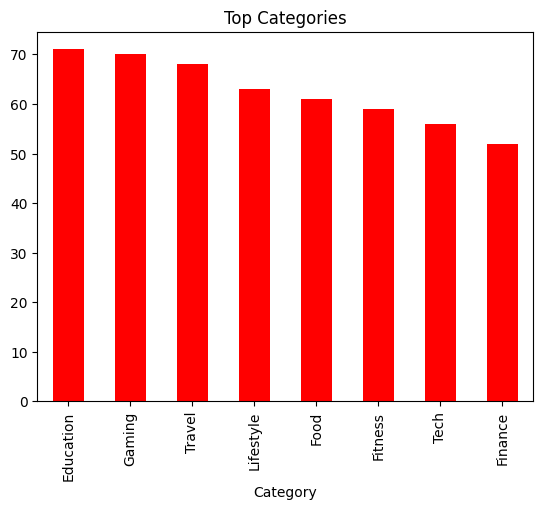

In [26]:
pdf = df.toPandas()

import matplotlib.pyplot as plt
pdf['Category'].value_counts().head(10).plot(kind='bar',color="red")
plt.title("Top Categories")
plt.show()

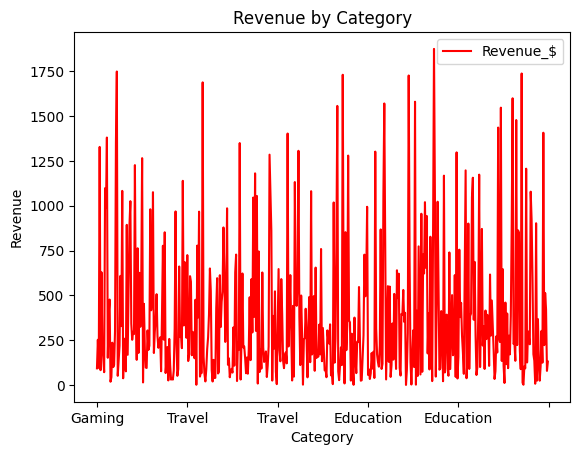

In [25]:
pdf.plot(x="Category", y="Revenue_$",kind="line",color="red")
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

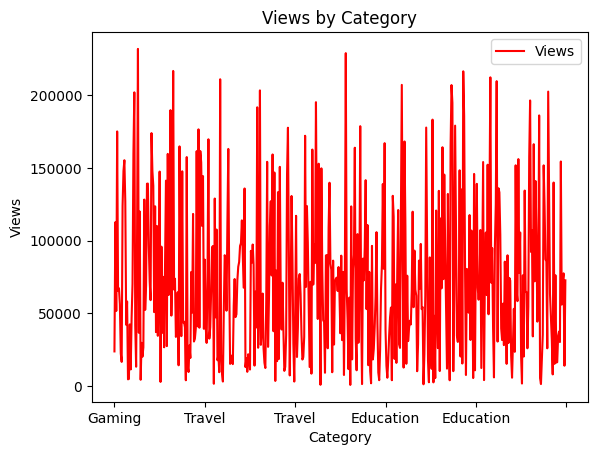

In [33]:
pdf.plot(x="Category", y="Views",kind="line",color="red")
plt.title("Views by Category")
plt.xlabel("Category")
plt.ylabel("Views")
plt.show()

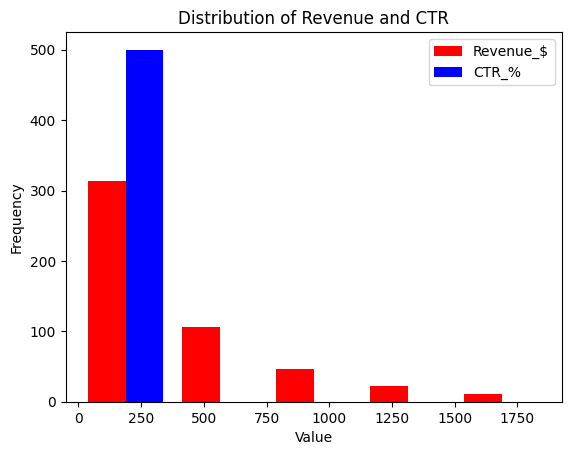

In [40]:
plt.hist([pdf["Revenue_$"], pdf["CTR_%"]], bins=5, color=["red", "blue"], label=["Revenue_$", "CTR_%"])
plt.title("Distribution of Revenue and CTR")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

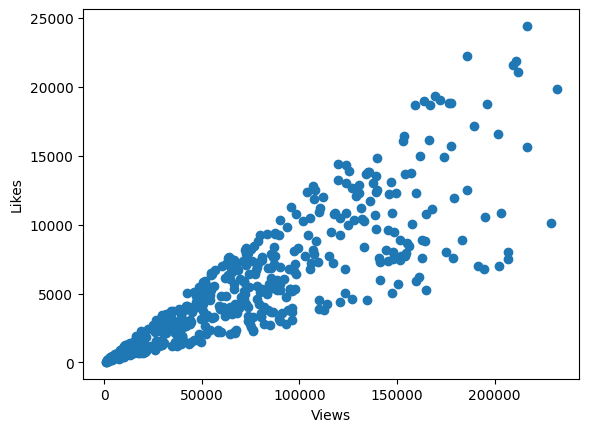

In [52]:
import matplotlib.pyplot as plt

plt.scatter(pdf['Views'], pdf['Likes'])
plt.xlabel("Views")
plt.ylabel("Likes")
plt.show()

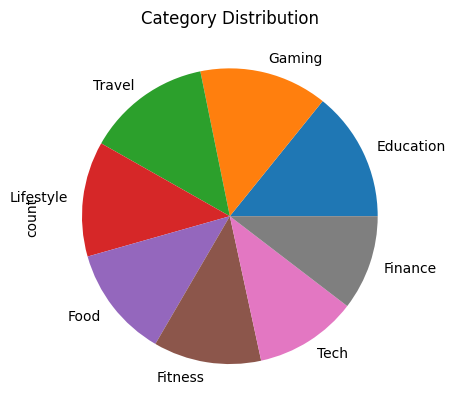

In [54]:
pdf['Category'].value_counts().plot(kind='pie')
plt.title("Category Distribution")
plt.show()